In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser, NoiseAdder, Normalizer

from config import TEST_SIZE, SEED, MAX_DURATION, MIN_DURATION, SAMPLING_RATE, N_MELS, N_FFT

In [25]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

In [26]:
df = pd.read_csv('./dataset/audios_ventanas/labels.csv')

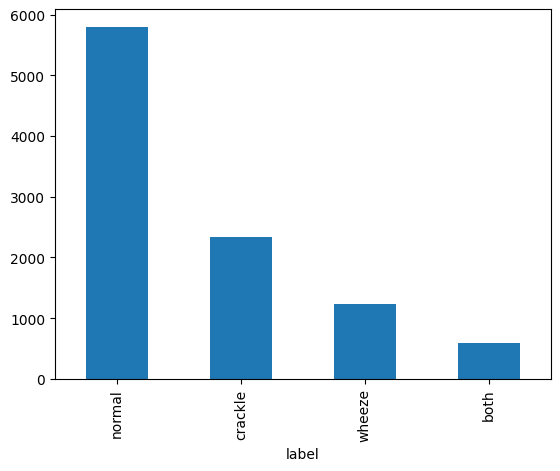

In [27]:
df.label.value_counts().plot(kind='bar');

In [28]:
df['label'] = df['label'].replace({'crackle': 1, 'wheeze': 1, 'both': 1, 'normal': 0})

C:\Users\nazar\AppData\Local\Temp\ipykernel_12648\1575328833.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'crackle': 1, 'wheeze': 1, 'both': 1, 'normal': 0})


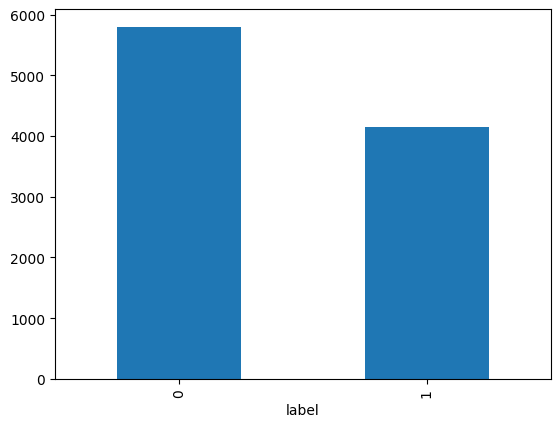

In [29]:
df.label.value_counts().plot(kind='bar');

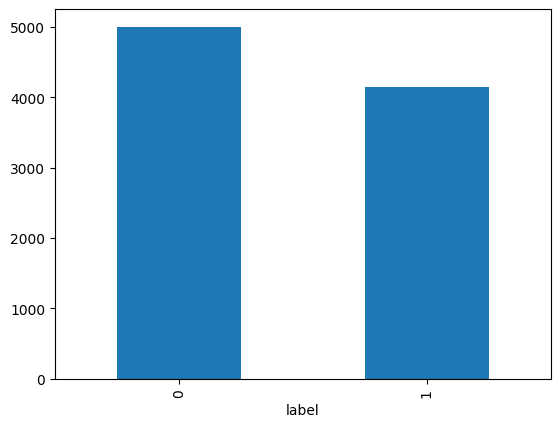

In [ ]:
df_normal = df[df['label'] == 0].sample(n=5000, random_state=SEED)
df_abnormal = df[df['label'] == 1]

df_balanced = pd.concat([df_normal, df_abnormal]).reset_index(drop=True)
df_balanced.label.value_counts().plot(kind='bar');